In [20]:
# Cell 1: Configuration, Index-Based Block Partitioning & Setup
# =============================================================================

import os
import joblib
import numpy as np
import pandas as pd

MODELS_DIR = "models"
BASE_DIR = "dataset/normalized"
AUG_DIR = os.path.join(BASE_DIR, "augmented_csv")
NODES = ["A", "B", "C", "D", "E", "F", "G", "H"]
TOTAL_BLOCKS = 43

# -----------------------------------------------------------------------------
# 1. Load Test Datasets & Assign Block IDs (1 to 43) via Row Index
# -----------------------------------------------------------------------------
aug_test = {}
for node in NODES:
    test_file_path = os.path.join(AUG_DIR, f"Node_{node}_combined_augmented_test.csv")
    df = pd.read_csv(test_file_path)
    
    # Calculate rows per block and assign block numbers (1 to 43)
    n_rows = len(df)
    block_size = n_rows // TOTAL_BLOCKS
    
    # Map row indices to 1-based block IDs (clamping remainder rows to block 43)
    block_ids = np.clip((np.arange(n_rows) // block_size) + 1, 1, TOTAL_BLOCKS)
    df["block_id"] = block_ids
    
    aug_test[node] = df
    print(f"Loaded Node {node}: {n_rows} rows (~{block_size} rows/block across {TOTAL_BLOCKS} blocks)")

# -----------------------------------------------------------------------------
# 2. Define the 9 Correlation Scenarios by Block IDs (1-based)
# -----------------------------------------------------------------------------
SCENARIOS = {
    "8 Attack / 0 None": [18, 19, 20, 21, 38, 39, 40, 41],
    "7 Attack / 1 None": [17, 37],
    "6 Attack / 2 None": [16, 36],
    "5 Attack / 3 None": [15, 35],
    "4 Attack / 4 None": [14, 34],
    "3 Attack / 5 None": [13, 33],
    "2 Attack / 6 None": [12, 32],
    "1 Attack / 7 None": [2, 3, 4, 5, 6, 7, 8, 9, 11, 23, 24, 25, 26, 27, 28, 29, 31],
    "0 Attack / 8 None": [1, 10, 22, 30, 42, 43]
}

# -----------------------------------------------------------------------------
# 3. Load Global Label Encoder & Baseline Artifacts
# -----------------------------------------------------------------------------
le = joblib.load(os.path.join(MODELS_DIR, f"Node_{NODES[0]}_label_encoder_context_w2.joblib"))
classes = le.classes_
num_classes = len(classes)
labels_arr = np.arange(num_classes)

# Define feature sets (without State)
original_numeric = ["shunt_voltage", "bus_voltage_V", "current_mA", "power_mW"]
agg_numeric = [f"agg_{f}" for f in original_numeric]
agg_prob_cols = [f"agg_prob_{cls_name}" for cls_name in classes]
own_prob_cols = [f"prob_{cls_name}" for cls_name in classes]

feature_cols_hw_plus_agg = original_numeric + agg_numeric + agg_prob_cols
feature_cols_full = original_numeric + own_prob_cols + agg_numeric + agg_prob_cols

print("\nSetup completed successfully.")
print(f"Classes: {classes}")

Loaded Node A: 21801 rows (~507 rows/block across 43 blocks)
Loaded Node B: 21801 rows (~507 rows/block across 43 blocks)
Loaded Node C: 21801 rows (~507 rows/block across 43 blocks)
Loaded Node D: 21801 rows (~507 rows/block across 43 blocks)
Loaded Node E: 21801 rows (~507 rows/block across 43 blocks)
Loaded Node F: 21801 rows (~507 rows/block across 43 blocks)
Loaded Node G: 21801 rows (~507 rows/block across 43 blocks)
Loaded Node H: 21801 rows (~507 rows/block across 43 blocks)

Setup completed successfully.
Classes: ['Backdoor' 'none' 'syn-flood']


In [21]:
# Cell 2: Multi-Model Inference Across the 9 Correlation Scenarios (Warning Handled)
# =============================================================================

import warnings
import numpy as np
import pandas as pd
from sklearn.metrics import (
    accuracy_score,
    f1_score,
    log_loss,
    mean_squared_error,
    roc_auc_score,
)

scenario_results = []

# Load Baseline Model & Scaler
rf_base = joblib.load(os.path.join(MODELS_DIR, "rf_final.joblib"))
scaler_base = joblib.load(os.path.join(MODELS_DIR, "scaler.joblib"))
base_numeric_cols = ["shunt_voltage", "bus_voltage_V", "current_mA", "power_mW"]
base_expected_order = [
    "shunt_voltage",
    "bus_voltage_V",
    "current_mA",
    "power_mW",
    "State_idle",
    "State_charging",
]

for scen_name, blocks in SCENARIOS.items():
    y_true_base, y_pred_base, y_prob_base = [], [], []
    y_true_m1, y_pred_m1, y_prob_m1 = [], [], []
    y_true_m2, y_pred_m2, y_prob_m2 = [], [], []

    for node in NODES:
        test_df = aug_test[node].copy()

        # Slice data for current scenario blocks
        scen_df = test_df[test_df["block_id"].isin(blocks)].copy()
        if len(scen_df) == 0:
            continue

        y_test_node = le.transform(scen_df["Attack"])

        # ---------------------------------------------------------------------
        # 1. Baseline Model (Uses own HW + State)
        # ---------------------------------------------------------------------
        X_b = pd.get_dummies(
            scen_df[
                [
                    "shunt_voltage",
                    "bus_voltage_V",
                    "current_mA",
                    "power_mW",
                    "State",
                ]
            ],
            columns=["State"],
            drop_first=False,
        )
        for col in ["State_idle", "State_charging"]:
            if col not in X_b.columns:
                X_b[col] = 0
        X_b_ordered = X_b[base_expected_order].copy()
        X_b_ordered[base_numeric_cols] = scaler_base.transform(
            X_b_ordered[base_numeric_cols]
        )

        prob_b = rf_base.predict_proba(X_b_ordered.to_numpy())
        pred_b = np.argmax(prob_b, axis=1)

        y_true_base.extend(y_test_node)
        y_pred_base.extend(pred_b)
        y_prob_base.append(prob_b)

        # ---------------------------------------------------------------------
        # 2. Model 1 (Own HW [2x] + Agg Context [1x])
        # ---------------------------------------------------------------------
        rf_m1 = joblib.load(
            os.path.join(
                MODELS_DIR,
                f"Node_{node}_rf_context_own_hw_plus_agg_w2.joblib",
            )
        )
        scaler_m1 = joblib.load(
            os.path.join(
                MODELS_DIR,
                f"Node_{node}_scaler_context_own_hw_plus_agg_w2.joblib",
            )
        )
        feat_m1 = pd.read_csv(
            os.path.join(
                MODELS_DIR,
                f"Node_{node}_feature_list_own_hw_plus_agg_w2.csv",
            )
        )["feature"].tolist()

        X_m1 = scen_df[feature_cols_hw_plus_agg].copy()
        own_cols_m1 = [
            c for c in feature_cols_hw_plus_agg if not c.startswith("agg_")
        ]
        for col in own_cols_m1:
            X_m1[f"{col}_w2"] = X_m1[col]

        num_cols_m1 = list(
            getattr(
                scaler_m1,
                "feature_names_in_",
                original_numeric
                + [f"{c}_w2" for c in original_numeric]
                + agg_numeric,
            )
        )
        X_m1[num_cols_m1] = scaler_m1.transform(X_m1[num_cols_m1])

        prob_1 = rf_m1.predict_proba(X_m1[feat_m1].to_numpy())
        pred_1 = np.argmax(prob_1, axis=1)

        y_true_m1.extend(y_test_node)
        y_pred_m1.extend(pred_1)
        y_prob_m1.append(prob_1)

        # ---------------------------------------------------------------------
        # 3. Model 2 (Full Context [2:1])
        # ---------------------------------------------------------------------
        rf_m2 = joblib.load(
            os.path.join(MODELS_DIR, f"Node_{node}_rf_context_full_w2.joblib")
        )
        scaler_m2 = joblib.load(
            os.path.join(
                MODELS_DIR, f"Node_{node}_scaler_context_full_w2.joblib"
            )
        )
        feat_m2 = pd.read_csv(
            os.path.join(
                MODELS_DIR, f"Node_{node}_feature_list_context_full_w2.csv"
            )
        )["feature"].tolist()

        X_m2 = scen_df[feature_cols_full].copy()
        own_cols_m2 = [
            c for c in feature_cols_full if not c.startswith("agg_")
        ]
        for col in own_cols_m2:
            X_m2[f"{col}_w2"] = X_m2[col]

        num_cols_m2 = list(
            getattr(
                scaler_m2,
                "feature_names_in_",
                original_numeric
                + [f"{c}_w2" for c in original_numeric]
                + agg_numeric,
            )
        )
        X_m2[num_cols_m2] = scaler_m2.transform(X_m2[num_cols_m2])

        prob_2 = rf_m2.predict_proba(X_m2[feat_m2].to_numpy())
        pred_2 = np.argmax(prob_2, axis=1)

        y_true_m2.extend(y_test_node)
        y_pred_m2.extend(pred_2)
        y_prob_m2.append(prob_2)

    # -------------------------------------------------------------------------
    # Helper to calculate metrics per scenario (Safe ROC-AUC Calculation)
    # -------------------------------------------------------------------------
    def evaluate_scenario(y_true, y_pred, y_prob, model_label):
        y_true_arr = np.array(y_true)
        y_pred_arr = np.array(y_pred)
        y_prob_arr = (
            np.concatenate(y_prob, axis=0) if len(y_prob) > 0 else np.array([])
        )

        acc = accuracy_score(y_true_arr, y_pred_arr)
        f1 = f1_score(y_true_arr, y_pred_arr, average="macro")
        mse = mean_squared_error(y_true_arr, y_pred_arr)
        loss = log_loss(y_true_arr, y_prob_arr, labels=labels_arr)

        # Check for at least 2 distinct classes before calculating ROC-AUC
        if len(np.unique(y_true_arr)) > 1:
            try:
                with warnings.catch_warnings():
                    warnings.simplefilter("ignore")
                    auc = roc_auc_score(
                        y_true_arr,
                        y_prob_arr,
                        multi_class="ovr",
                        average="macro",
                        labels=labels_arr,
                    )
            except ValueError:
                auc = np.nan
        else:
            auc = np.nan

        return {
            "Scenario": scen_name,
            "Model": model_label,
            "Samples": len(y_true_arr),
            "Accuracy": round(acc, 6),
            "Macro F1": round(f1, 6),
            "MSE": round(mse, 6),
            "Log Loss": round(loss, 6),
            "ROC-AUC": round(auc, 6),
        }

    scenario_results.append(
        evaluate_scenario(y_true_base, y_pred_base, y_prob_base, "Baseline RF")
    )
    scenario_results.append(
        evaluate_scenario(
            y_true_m1,
            y_pred_m1,
            y_prob_m1,
            "Model 1 (Own HW [2x] + Agg [1x])",
        )
    )
    scenario_results.append(
        evaluate_scenario(
            y_true_m2, y_pred_m2, y_prob_m2, "Model 2 (Full Context [2:1])"
        )
    )

df_scen = pd.DataFrame(scenario_results)
print("=== Performance Across All 9 Correlation Scenarios ===")
print(df_scen.to_string(index=False))

=== Performance Across All 9 Correlation Scenarios ===
         Scenario                            Model  Samples  Accuracy  Macro F1      MSE  Log Loss  ROC-AUC
8 Attack / 0 None                      Baseline RF    32448  0.826029  0.592598 0.218257  0.378510      NaN
8 Attack / 0 None Model 1 (Own HW [2x] + Agg [1x])    32448  0.899008  0.629127 0.102009  0.545588      NaN
8 Attack / 0 None     Model 2 (Full Context [2:1])    32448  0.838480  0.598929 0.199057  1.802844      NaN
7 Attack / 1 None                      Baseline RF     8112  0.856879  0.815317 0.167160  0.289879 0.996030
7 Attack / 1 None Model 1 (Own HW [2x] + Agg [1x])     8112  0.920735  0.886374 0.080005  0.256346 0.996298
7 Attack / 1 None     Model 2 (Full Context [2:1])     8112  0.866124  0.825365 0.156435  1.405486 0.981175
6 Attack / 2 None                      Baseline RF     8112  0.891149  0.884182 0.124014  0.226250 0.994841
6 Attack / 2 None Model 1 (Own HW [2x] + Agg [1x])     8112  0.959689  0.956214 0

Saved metric-by-metric comparison plot to 'plots/scenarios_metric_by_metric_comparison.png'


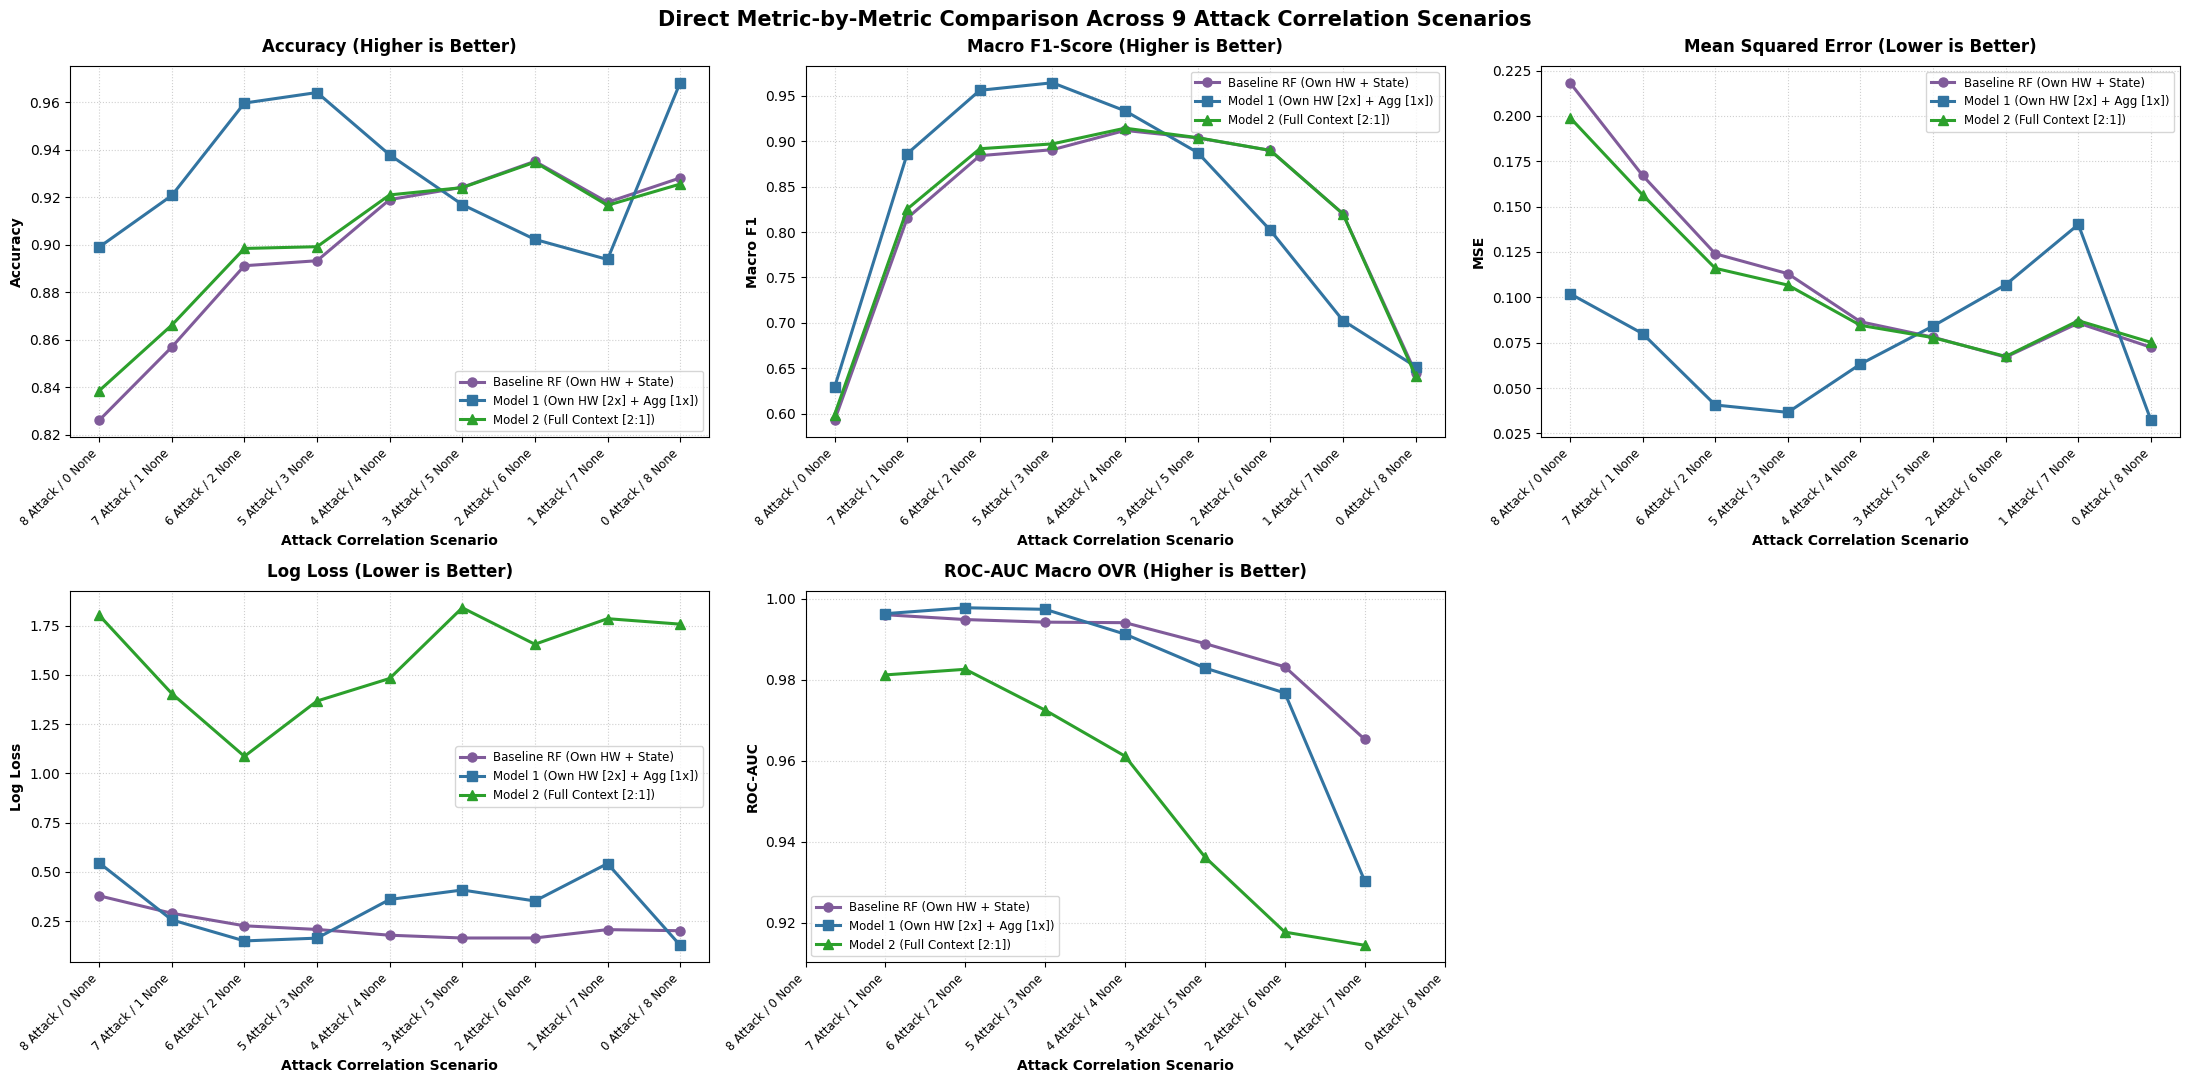

In [22]:
# Cell 4
# =============================================================================
# Subplots per Metric: Comparing All 3 Models Across the 9 Scenarios
# =============================================================================

import os
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

PLOTS_DIR = "plots"
os.makedirs(PLOTS_DIR, exist_ok=True)

scen_order = list(SCENARIOS.keys())
x_indices = np.arange(len(scen_order))

model_styles = {
    "Baseline RF": {
        "color": "#805B9A",
        "marker": "o",
        "linestyle": "-",
        "label": "Baseline RF (Own HW + State)"
    },
    "Model 1 (Own HW [2x] + Agg [1x])": {
        "color": "#3274A1",
        "marker": "s",
        "linestyle": "-",
        "label": "Model 1 (Own HW [2x] + Agg [1x])"
    },
    "Model 2 (Full Context [2:1])": {
        "color": "#2CA02C",
        "marker": "^",
        "linestyle": "-",
        "label": "Model 2 (Full Context [2:1])"
    }
}

metrics_to_plot = [
    ("Accuracy", "Accuracy (Higher is Better)"),
    ("Macro F1", "Macro F1-Score (Higher is Better)"),
    ("MSE", "Mean Squared Error (Lower is Better)"),
    ("Log Loss", "Log Loss (Lower is Better)"),
    ("ROC-AUC", "ROC-AUC Macro OVR (Higher is Better)")
]

fig, axes = plt.subplots(2, 3, figsize=(22, 11))
axes_flat = axes.flatten()

for idx, (metric_col, metric_title) in enumerate(metrics_to_plot):
    ax = axes_flat[idx]

    for model_name, style in model_styles.items():
        df_model = (
            df_scen[df_scen["Model"] == model_name]
            .set_index("Scenario")
            .reindex(scen_order)
        )
        y_values = df_model[metric_col].values

        ax.plot(
            x_indices,
            y_values,
            color=style["color"],
            marker=style["marker"],
            linestyle=style["linestyle"],
            linewidth=2.2,
            markersize=6.5,
            label=style["label"]
        )

    ax.set_title(metric_title, fontsize=12, fontweight="bold", pad=10)
    ax.set_xlabel("Attack Correlation Scenario", fontsize=10, fontweight="bold")
    ax.set_ylabel(metric_col, fontsize=10, fontweight="bold")
    ax.set_xticks(x_indices)
    ax.set_xticklabels(scen_order, rotation=45, ha="right", fontsize=8.5)
    ax.grid(True, linestyle=":", alpha=0.6)
    ax.legend(loc="best", fontsize=8.5, frameon=True)

# Remove unused 6th subplot cell
fig.delaxes(axes_flat[-1])

fig.suptitle(
    "Direct Metric-by-Metric Comparison Across 9 Attack Correlation Scenarios",
    fontsize=15,
    fontweight="bold",
    y=0.98
)

plt.tight_layout()

# Save plot
output_path = os.path.join(PLOTS_DIR, "scenarios_metric_by_metric_comparison.png")
fig.savefig(output_path, dpi=300, bbox_inches="tight")
print(f"Saved metric-by-metric comparison plot to '{output_path}'")

plt.show()
plt.close(fig)

Saved complete 9x3 confusion matrix grid to 'plots/scenarios_all_confusion_matrices_grid.png'


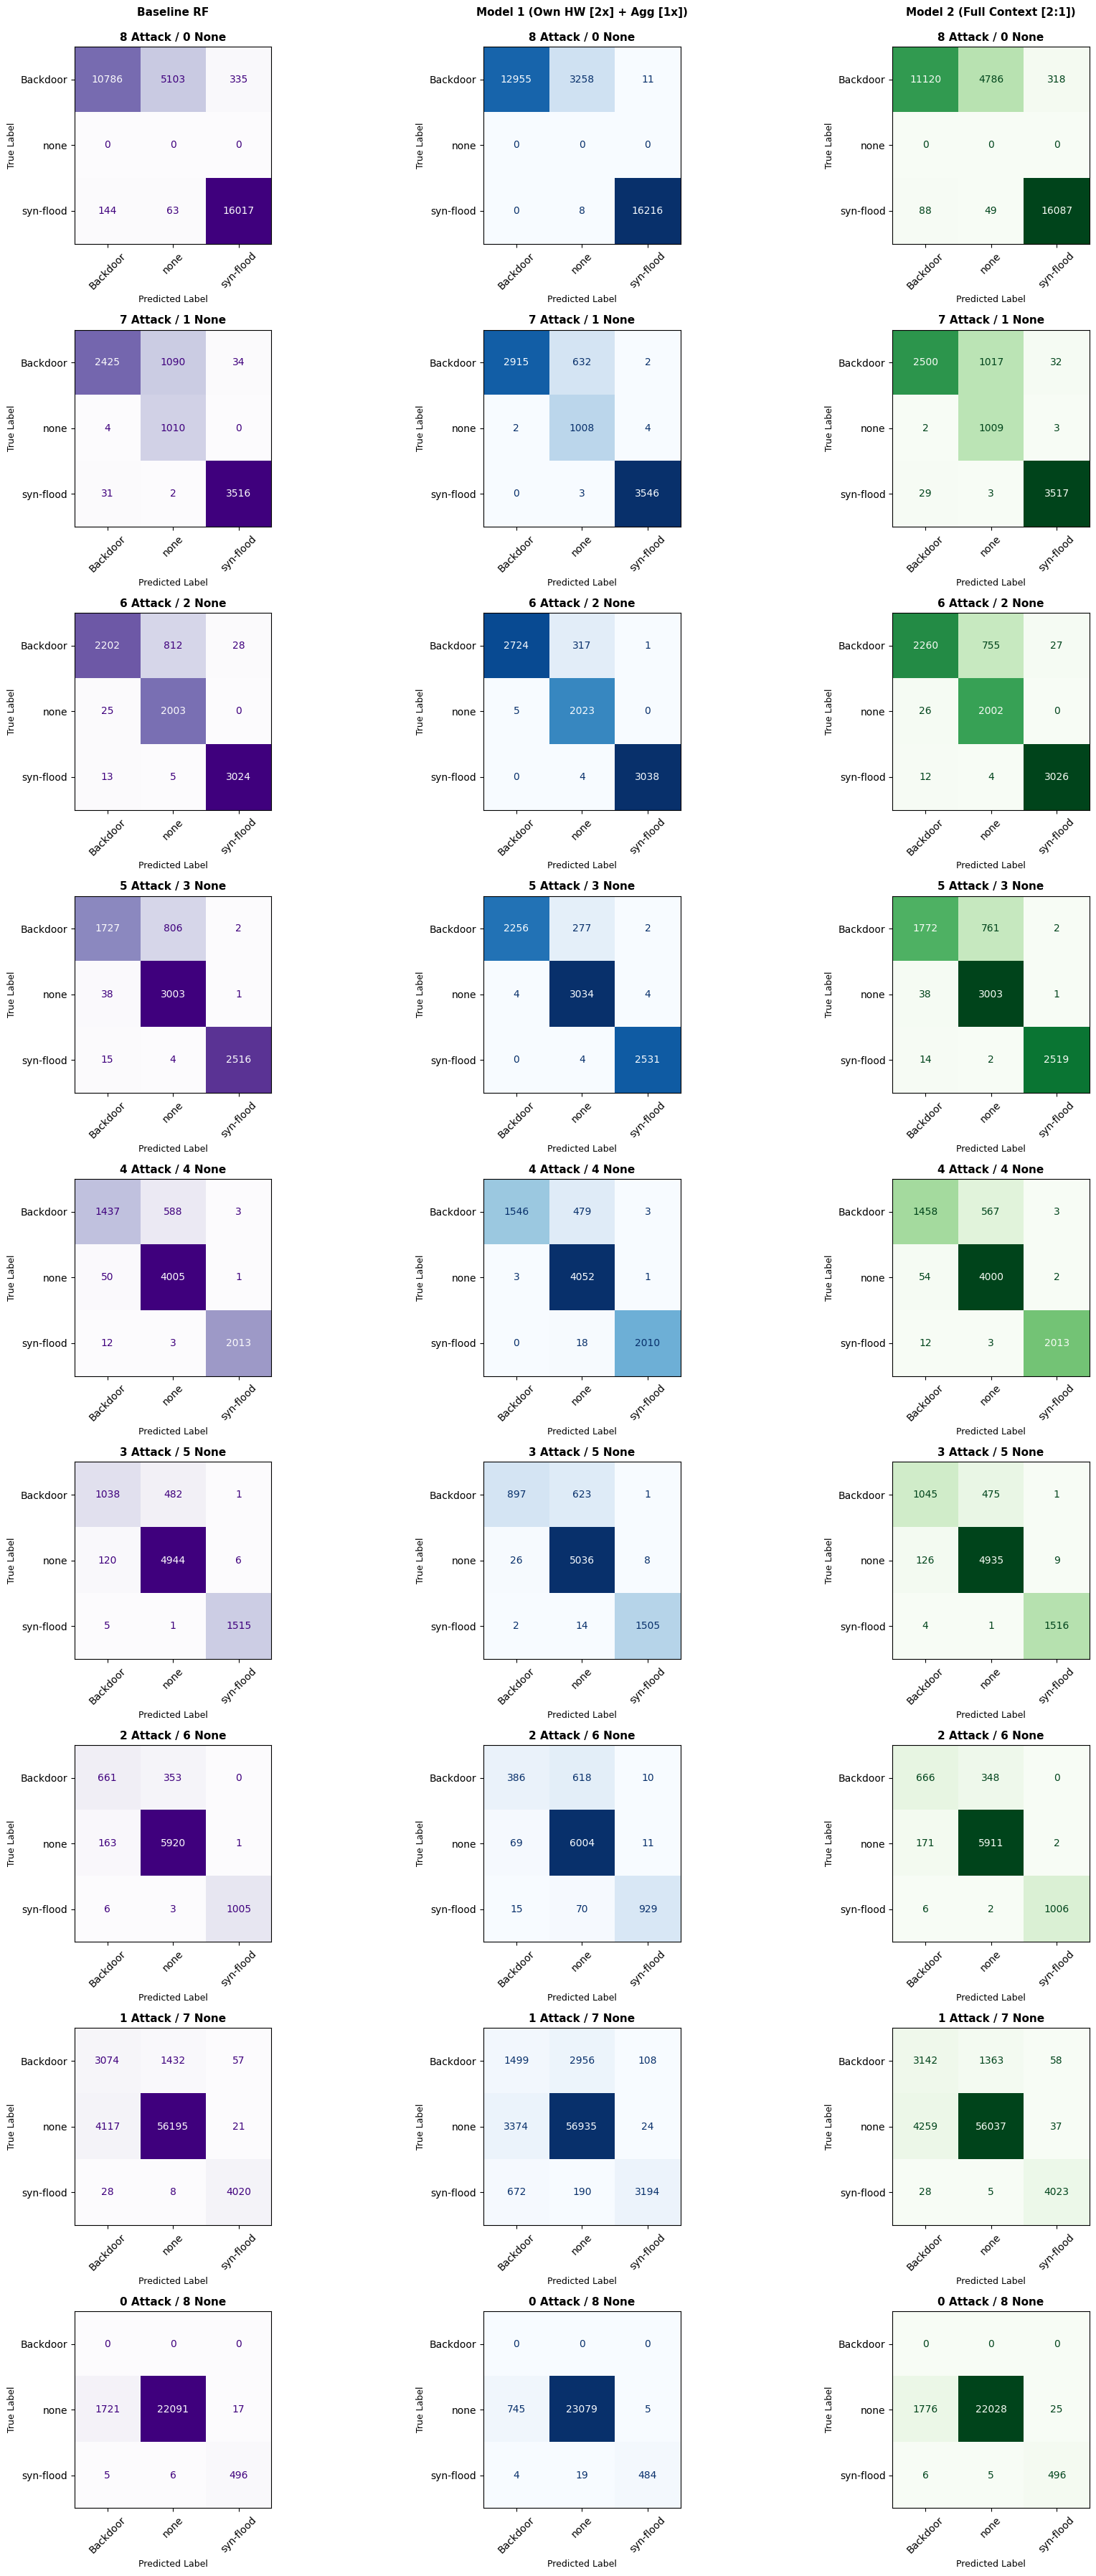

In [23]:
# Cell 5
# =============================================================================
# Multi-Panel Confusion Matrix Grid: 9 Scenarios x 3 Models (Attack Types)
# =============================================================================

import os
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn.metrics import ConfusionMatrixDisplay, confusion_matrix

PLOTS_DIR = "plots"
os.makedirs(PLOTS_DIR, exist_ok=True)

scen_order = list(SCENARIOS.keys())
n_scenarios = len(scen_order)
n_models = 3

fig, axes = plt.subplots(n_scenarios, n_models, figsize=(18, 4 * n_scenarios))

# Baseline artifacts loaded once
rf_base = joblib.load(os.path.join(MODELS_DIR, "rf_final.joblib"))
scaler_base = joblib.load(os.path.join(MODELS_DIR, "scaler.joblib"))
base_numeric_cols = ["shunt_voltage", "bus_voltage_V", "current_mA", "power_mW"]
base_expected_order = [
    "shunt_voltage", "bus_voltage_V", "current_mA", "power_mW",
    "State_idle", "State_charging"
]

for row_idx, scen_name in enumerate(scen_order):
    blocks = SCENARIOS[scen_name]
    
    y_true_list = []
    y_pred_base_list = []
    y_pred_m1_list = []
    y_pred_m2_list = []

    for node in NODES:
        test_df = aug_test[node].copy()
        scen_df = test_df[test_df["block_id"].isin(blocks)].copy()
        if len(scen_df) == 0:
            continue

        y_test_node = le.transform(scen_df["Attack"])
        y_true_list.extend(y_test_node)

        # ---------------------------------------------------------------------
        # 1. Baseline Predictions
        # ---------------------------------------------------------------------
        X_b = pd.get_dummies(
            scen_df[["shunt_voltage", "bus_voltage_V", "current_mA", "power_mW", "State"]],
            columns=["State"],
            drop_first=False
        )
        for col in ["State_idle", "State_charging"]:
            if col not in X_b.columns:
                X_b[col] = 0
        X_b_ordered = X_b[base_expected_order].copy()
        X_b_ordered[base_numeric_cols] = scaler_base.transform(X_b_ordered[base_numeric_cols])
        pred_b = np.argmax(rf_base.predict_proba(X_b_ordered.to_numpy()), axis=1)
        y_pred_base_list.extend(pred_b)

        # ---------------------------------------------------------------------
        # 2. Model 1 Predictions
        # ---------------------------------------------------------------------
        rf_m1 = joblib.load(os.path.join(MODELS_DIR, f"Node_{node}_rf_context_own_hw_plus_agg_w2.joblib"))
        scaler_m1 = joblib.load(os.path.join(MODELS_DIR, f"Node_{node}_scaler_context_own_hw_plus_agg_w2.joblib"))
        feat_m1 = pd.read_csv(os.path.join(MODELS_DIR, f"Node_{node}_feature_list_own_hw_plus_agg_w2.csv"))["feature"].tolist()

        X_m1 = scen_df[feature_cols_hw_plus_agg].copy()
        for col in [c for c in feature_cols_hw_plus_agg if not c.startswith("agg_")]:
            X_m1[f"{col}_w2"] = X_m1[col]

        num_cols_m1 = list(getattr(scaler_m1, "feature_names_in_", original_numeric + [f"{c}_w2" for c in original_numeric] + agg_numeric))
        X_m1[num_cols_m1] = scaler_m1.transform(X_m1[num_cols_m1])
        pred_1 = np.argmax(rf_m1.predict_proba(X_m1[feat_m1].to_numpy()), axis=1)
        y_pred_m1_list.extend(pred_1)

        # ---------------------------------------------------------------------
        # 3. Model 2 Predictions
        # ---------------------------------------------------------------------
        rf_m2 = joblib.load(os.path.join(MODELS_DIR, f"Node_{node}_rf_context_full_w2.joblib"))
        scaler_m2 = joblib.load(os.path.join(MODELS_DIR, f"Node_{node}_scaler_context_full_w2.joblib"))
        feat_m2 = pd.read_csv(os.path.join(MODELS_DIR, f"Node_{node}_feature_list_context_full_w2.csv"))["feature"].tolist()

        X_m2 = scen_df[feature_cols_full].copy()
        for col in [c for c in feature_cols_full if not c.startswith("agg_")]:
            X_m2[f"{col}_w2"] = X_m2[col]

        num_cols_m2 = list(getattr(scaler_m2, "feature_names_in_", original_numeric + [f"{c}_w2" for c in original_numeric] + agg_numeric))
        X_m2[num_cols_m2] = scaler_m2.transform(X_m2[num_cols_m2])
        pred_2 = np.argmax(rf_m2.predict_proba(X_m2[feat_m2].to_numpy()), axis=1)
        y_pred_m2_list.extend(pred_2)

    # -------------------------------------------------------------------------
    # Render Confusion Matrices for Row (Scenario)
    # -------------------------------------------------------------------------
    y_true_arr = np.array(y_true_list)
    model_predictions = [
        ("Baseline RF", np.array(y_pred_base_list), "Purples"),
        ("Model 1 (Own HW [2x] + Agg [1x])", np.array(y_pred_m1_list), "Blues"),
        ("Model 2 (Full Context [2:1])", np.array(y_pred_m2_list), "Greens"),
    ]

    for col_idx, (model_title, y_pred_arr, cmap) in enumerate(model_predictions):
        ax = axes[row_idx, col_idx]
        cm = confusion_matrix(y_true_arr, y_pred_arr, labels=labels_arr)
        disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=classes)
        disp.plot(ax=ax, cmap=cmap, colorbar=False, values_format="d")

        if row_idx == 0:
            ax.set_title(f"{model_title}\n\n{scen_name}", fontsize=11, fontweight="bold")
        else:
            ax.set_title(scen_name, fontsize=11, fontweight="bold")

        ax.set_xlabel("Predicted Label", fontsize=9)
        ax.set_ylabel("True Label", fontsize=9)
        ax.tick_params(axis="x", rotation=45)

plt.tight_layout()

output_path = os.path.join(PLOTS_DIR, "scenarios_all_confusion_matrices_grid.png")
fig.savefig(output_path, dpi=300, bbox_inches="tight")
print(f"Saved complete 9x3 confusion matrix grid to '{output_path}'")

plt.show()
plt.close(fig)